In [1]:
import os
import csv
import json

"""
This script reads the CSV files generated by the experiment and saves the results in a single JSON file.
It stores the coarse and fine results in lists so that the row order (index) is preserved.
"""

experiment_folder = "/app/bindmount/results/csv"
result_dict = {}

# Iterate over all experiment folders (e.g. "763620_exp")
for folder in os.listdir(experiment_folder):
    folder_path = os.path.join(experiment_folder, folder)
    if os.path.isdir(folder_path):
        # Extract the source number from the folder name (e.g. "763620" from "763620_exp")
        source_num = folder.split("_")[0]
        # Initialize lists for coarse and fine results instead of dicts keyed by rank
        result_dict[source_num] = {"coarse_result": [], "fine_result": []}

        # Define the paths to the CSV files
        coarse_path = os.path.join(folder_path, "coarse_filtering_results.csv")
        fine_path = os.path.join(folder_path, "fine_filtering_results.csv")

        # Process the coarse filtering results CSV
        with open(coarse_path, "r", newline="") as csv_file:
            reader = csv.DictReader(csv_file)
            for row in reader:
                result_dict[source_num]["coarse_result"].append({
                    "CAD": row["CAD"],
                    "Eigen Score": row["Eigen Score (lower is better)"],
                    "BBox Score": row["BBox Score"],
                })

        # Process the fine filtering results CSV
        with open(fine_path, "r", newline="") as csv_file:
            reader = csv.DictReader(csv_file)
            for row in reader:
                result_dict[source_num]["fine_result"].append({
                    "CAD": row["CAD"],
                    "RANSAC Fitness": row["RANSAC Fitness"],
                    "RANSAC RMSE": row["RANSAC RMSE"],
                    "Num Inliers": row["Num Inliers"],
                })

output_file = "/app/bindmount/complete_result/experiment1/dict.json"
# Ensure the directory exists
os.makedirs(os.path.dirname(output_file), exist_ok=True)

with open(output_file, "w") as f:
    json.dump(result_dict, f, indent=4)

print(f"Experiment results saved to {output_file}")

Experiment results saved to /app/bindmount/complete_result/experiment1/dict.json


In [2]:
import os
import json
import pandas as pd
    
# Define the JSON file path
json_file = "app/bindmount/complete_result/experiment1/dict.json"

# Load the complete experiment results from JSON
with open(json_file, "r") as f:
    result_dict = json.load(f)

experiment = result_dict["763621"]

# Convert the coarse and fine results (which are stored as lists) into DataFrames.
df_coarse = pd.DataFrame(experiment["coarse_result"]).T
df_fine = pd.DataFrame(experiment["fine_result"]).T

merged_df = pd.merge(df_coarse, df_fine, on="CAD", how="outer")
merged_df.drop(columns=["Eigenvalues"], inplace=True)
merged_df

,CAD,Eigen Score,BBox Score,RANSAC Fitness,RANSAC RMSE,Num Inliers
0,8121694,0.5866,1.5331,0.4877,0.0111,1463
1,8121692,0.5910,1.5331,0.9050,0.0078,2715
2,794601,0.7843,1.5752,1.0000,0.0043,3000
3,798512,0.8244,1.5391,1.0000,0.0049,3000
4,8141343,0.8583,1.5562,0.0000,0.0000,0
...,...,...,...,...,...,...
309,783475,647.9386,1.8319,NaN,NaN,NaN
310,8111409,802.7556,1.5073,NaN,NaN,NaN
311,8111520,1004.3212,0.8635,NaN,NaN,NaN
312,785185,1085.4276,2.6056,NaN,NaN,NaN


In [3]:
def load_experiment_by_number(json_file, experiment_number):
    with open(json_file, "r") as f:
        result_dict = json.load(f)
        
    experiment = result_dict[experiment_number]
        
    # Convert the coarse and fine results (which are stored as lists) into DataFrames.
    df_coarse = pd.DataFrame(experiment["coarse_result"]).T
    df_fine = pd.DataFrame(experiment["fine_result"]).T

    merged_df = pd.merge(df_coarse, df_fine, on="CAD", how="outer")
    merged_df.drop(columns=["Eigenvalues"], inplace=True)
    for col in merged_df.columns:
        try:
            merged_df[col] = pd.to_numeric(merged_df[col])
        except ValueError:
            pass
    return merged_df

# example
json_file = "app/bindmount/complete_result/experiment1/dict.json"
load_experiment_by_number(json_file, "763620")

,CAD,Eigen Score,BBox Score,RANSAC Fitness,RANSAC RMSE,Num Inliers
0,8121694,0.5923,1.5328,0.8613,0.0094,2584.0
1,8121692,0.5967,1.5328,0.8860,0.0101,2658.0
2,794601,0.7882,1.5751,1.0000,0.0048,3000.0
3,798512,0.8197,1.5390,1.0000,0.0050,3000.0
4,8141343,0.8594,1.5559,0.0000,0.0000,0.0
...,...,...,...,...,...,...
309,783475,644.6579,1.8386,NaN,NaN,NaN
310,8111409,798.5798,1.5128,NaN,NaN,NaN
311,8111520,997.2294,0.8617,NaN,NaN,NaN
312,785185,1080.4914,2.6142,NaN,NaN,NaN


In [4]:
def coarse_filtering_evaluation(json_file, scan_number) -> dict:
    """
    Compute stats for the coarse filtering:
      - Calculate Eigen Score and BBox Score statistics.
      - Sort the experiment by various criteria and return the rank (1-indexed)
        of the target scan in the sorted order.
    """
    df = load_experiment_by_number(json_file, scan_number)

    # Calculate statistics (assuming the columns are numeric)
    eig_score_mean = df["Eigen Score"].mean()
    eig_score_std  = df["Eigen Score"].std()
    eig_score_min  = df["Eigen Score"].min()
    eig_score_max  = df["Eigen Score"].max()
    bbox_score_mean = df["BBox Score"].mean()
    bbox_score_std  = df["BBox Score"].std()
    bbox_score_min  = df["BBox Score"].min()
    bbox_score_max  = df["BBox Score"].max()

    # Convert "CAD" to string and strip extra whitespace
    df["CAD"] = df["CAD"].astype(str).str.strip()
    scan_number = str(scan_number).strip()

    # Sort by Eigen Score, reset index so that rank is based on the new order,
    # and extract the rank of the target scan (if found)
    df_eig = df.sort_values("Eigen Score", ascending=True).reset_index(drop=True)
    if not df_eig[df_eig["CAD"] == scan_number].empty:
        eig_matching_index = df_eig[df_eig["CAD"] == scan_number].index[0] + 1
    else:
        eig_matching_index = None

    # Sort by BBox Score
    df_bbox = df.sort_values("BBox Score", ascending=True).reset_index(drop=True)
    if not df_bbox[df_bbox["CAD"] == scan_number].empty:
        bbox_matching_index = df_bbox[df_bbox["CAD"] == scan_number].index[0] + 1
    else:
        bbox_matching_index = None
    
    # Sort by Eigen Score then BBox Score
    df_eig_bbox = df.sort_values(["Eigen Score", "BBox Score"], ascending=True).reset_index(drop=True)
    if not df_eig_bbox[df_eig_bbox["CAD"] == scan_number].empty:
        eig_bbox_matching_index = df_eig_bbox[df_eig_bbox["CAD"] == scan_number].index[0] + 1
    else:
        eig_bbox_matching_index = None
    
    # Sort by BBox Score then Eigen Score
    df_bbox_eig = df.sort_values(["BBox Score", "Eigen Score"], ascending=True).reset_index(drop=True)
    if not df_bbox_eig[df_bbox_eig["CAD"] == scan_number].empty:
        bbox_eig_matching_index = df_bbox_eig[df_bbox_eig["CAD"] == scan_number].index[0] + 1
    else:
        bbox_eig_matching_index = None

    result = {
        "eig_score_mean": eig_score_mean,
        "eig_score_std": eig_score_std,
        "eig_score_min": eig_score_min,
        "eig_score_max": eig_score_max,
        "bbox_score_mean": bbox_score_mean,
        "bbox_score_std": bbox_score_std,
        "bbox_score_min": bbox_score_min,
        "bbox_score_max": bbox_score_max,
        "eig_matching_index": eig_matching_index,
        "bbox_matching_index": bbox_matching_index,
        "eig_bbox_matching_index": eig_bbox_matching_index,
        "bbox_eig_matching_index": bbox_eig_matching_index
    }
    return result

# example
json_file = "app/bindmount/complete_result/experiment1/dict.json"
scan_number = "763620"
coarse_filtering_evaluation(json_file, scan_number)

{'eig_score_mean': 147.88161337579618,
 'eig_score_std': 183.5384374361839,
 'eig_score_min': 0.5923,
 'eig_score_max': 1111.872,
 'bbox_score_mean': 1.1305585987261146,
 'bbox_score_std': 0.4372992386171679,
 'bbox_score_min': 0.264,
 'bbox_score_max': 3.6595,
 'eig_matching_index': 6,
 'bbox_matching_index': 281,
 'eig_bbox_matching_index': 6,
 'bbox_eig_matching_index': 280}

In [14]:
def fine_filtering_evaluation(json_file, scan_number):
    """
    Compute the stats for the fine filtering:
      - Calculate statistics for RANSAC Fitness, RANSAC RMSE, and number of inliers.
      - For each sorting criterion, sort the DataFrame, reset the index,
        and return the 1-indexed rank of the target scan.
    """
    df = load_experiment_by_number(json_file, scan_number)

    # Calculate statistics (assuming the columns are numeric)
    ransac_fitness_mean = df["RANSAC Fitness"].mean()
    ransac_fitness_std = df["RANSAC Fitness"].std()
    ransac_fitness_min = df["RANSAC Fitness"].min()
    ransac_fitness_max = df["RANSAC Fitness"].max()
    
    ransac_rmse_mean = df["RANSAC RMSE"].mean()
    ransac_rmse_std = df["RANSAC RMSE"].std()
    ransac_rmse_min = df["RANSAC RMSE"].min()
    ransac_rmse_max = df["RANSAC RMSE"].max()
    
    num_inliers_mean = df["Num Inliers"].mean()
    num_inliers_std = df["Num Inliers"].std()
    num_inliers_min = df["Num Inliers"].min()
    num_inliers_max = df["Num Inliers"].max()

    # Convert "CAD" to string and strip any extra whitespace
    df["CAD"] = df["CAD"].astype(str).str.strip()
    scan_number = str(scan_number).strip()

    # --- Determine matching ranks ---
    # Sort by RANSAC Fitness
    df_fitness = df.sort_values("RANSAC Fitness", ascending=True).reset_index(drop=True)
    if not df_fitness[df_fitness["CAD"] == scan_number].empty:
        fitness_matching_index = df_fitness[df_fitness["CAD"] == scan_number].index[0] + 1
    else:
        fitness_matching_index = None
    
    # Sort by RANSAC RMSE
    df_rmse = df.sort_values("RANSAC RMSE", ascending=True).reset_index(drop=True)
    if not df_rmse[df_rmse["CAD"] == scan_number].empty:
        rmse_matching_index = df_rmse[df_rmse["CAD"] == scan_number].index[0] + 1
    else:
        rmse_matching_index = None

    # Sort by RANSAC Fitness then RANSAC RMSE
    df_fitness_rmse = df.sort_values(["RANSAC Fitness", "RANSAC RMSE"], ascending=True).reset_index(drop=True)
    if not df_fitness_rmse[df_fitness_rmse["CAD"] == scan_number].empty:
        fitness_rmse_matching_index = df_fitness_rmse[df_fitness_rmse["CAD"] == scan_number].index[0] + 1
    else:
        fitness_rmse_matching_index = None

    # Sort by RANSAC RMSE then RANSAC Fitness
    df_rmse_fitness = df.sort_values(["RANSAC RMSE", "RANSAC Fitness"], ascending=True).reset_index(drop=True)
    if not df_rmse_fitness[df_rmse_fitness["CAD"] == scan_number].empty:
        rmse_fitness_matching_index = df_rmse_fitness[df_rmse_fitness["CAD"] == scan_number].index[0] + 1
    else:
        rmse_fitness_matching_index = None

    result = {
        "ransac_fitness_mean": ransac_fitness_mean,
        "ransac_fitness_std": ransac_fitness_std,
        "ransac_fitness_min": ransac_fitness_min,
        "ransac_fitness_max": ransac_fitness_max,
        "ransac_rmse_mean": ransac_rmse_mean,
        "ransac_rmse_std": ransac_rmse_std,
        "ransac_rmse_min": ransac_rmse_min,
        "ransac_rmse_max": ransac_rmse_max,
        "num_inliers_mean": num_inliers_mean,
        "num_inliers_std": num_inliers_std,
        "num_inliers_min": num_inliers_min,
        "num_inliers_max": num_inliers_max,
        "fitness_matching_index": fitness_matching_index,
        "rmse_matching_index": rmse_matching_index,
        "fitness_rmse_matching_index": fitness_rmse_matching_index,
        "rmse_fitness_matching_index": rmse_fitness_matching_index,
    }
    return result

# example
json_file = "app/bindmount/complete_result/experiment1/dict.json"
scan_number = "763620"
fine_filtering_evaluation(json_file, scan_number)

{'ransac_fitness_mean': 0.8608111111111111,
 'ransac_fitness_std': 0.32746598466269916,
 'ransac_fitness_min': 0.0,
 'ransac_fitness_max': 1.0,
 'ransac_rmse_mean': 0.004199999999999999,
 'ransac_rmse_std': 0.0035411862419251544,
 'ransac_rmse_min': 0.0,
 'ransac_rmse_max': 0.0101,
 'num_inliers_mean': 2582.4444444444443,
 'num_inliers_std': 982.3979732154264,
 'num_inliers_min': 0.0,
 'num_inliers_max': 3000.0,
 'fitness_matching_index': 6,
 'rmse_matching_index': 2,
 'fitness_rmse_matching_index': 4,
 'rmse_fitness_matching_index': 2}

In [6]:
from tqdm import tqdm
import json

# Define the JSON file path
json_file_path = "app/bindmount/complete_result/experiment1/dict.json"

# Load the complete experiment results from JSON
with open(json_file_path, "r") as f:
    result_dict = json.load(f)

# remove last observation because there is a problem with it
last_key = list(result_dict.keys())[-1]
result_dict.pop(last_key)

rank_evaluations = {}

for scan_number in tqdm(result_dict.keys(), desc="Processing scans"):
    # Run both evaluation functions for the given scan number
    coarse_result = coarse_filtering_evaluation(json_file_path, scan_number)
    fine_result = fine_filtering_evaluation(json_file_path, scan_number)
    
    # Initialize the dictionary for the current scan_number
    rank_evaluations[scan_number] = {}
    
    # coarse results
    rank_evaluations[scan_number]["eig_score_mean"] = coarse_result["eig_score_mean"]
    rank_evaluations[scan_number]["eig_score_std"] = coarse_result["eig_score_std"]
    rank_evaluations[scan_number]["eig_score_min"] = coarse_result["eig_score_min"]
    rank_evaluations[scan_number]["eig_score_max"] = coarse_result["eig_score_max"]
    rank_evaluations[scan_number]["bbox_score_mean"] = coarse_result["bbox_score_mean"]
    rank_evaluations[scan_number]["bbox_score_std"] = coarse_result["bbox_score_std"]
    rank_evaluations[scan_number]["bbox_score_min"] = coarse_result["bbox_score_min"]
    rank_evaluations[scan_number]["bbox_score_max"] = coarse_result["bbox_score_max"]
    rank_evaluations[scan_number]["eig_matching_index"] = coarse_result["eig_matching_index"]
    rank_evaluations[scan_number]["bbox_matching_index"] = coarse_result["bbox_matching_index"]
    rank_evaluations[scan_number]["eig_bbox_matching_index"] = coarse_result["eig_bbox_matching_index"]
    rank_evaluations[scan_number]["bbox_eig_matching_index"] = coarse_result["bbox_eig_matching_index"]
    
    # fine results
    rank_evaluations[scan_number]["ransac_fitness_mean"] = fine_result["ransac_fitness_mean"]
    rank_evaluations[scan_number]["ransac_fitness_std"] = fine_result["ransac_fitness_std"]
    rank_evaluations[scan_number]["ransac_fitness_min"] = fine_result["ransac_fitness_min"]
    rank_evaluations[scan_number]["ransac_fitness_max"] = fine_result["ransac_fitness_max"]
    rank_evaluations[scan_number]["ransac_rmse_mean"] = fine_result["ransac_rmse_mean"]
    rank_evaluations[scan_number]["ransac_rmse_std"] = fine_result["ransac_rmse_std"]
    rank_evaluations[scan_number]["ransac_rmse_min"] = fine_result["ransac_rmse_min"]
    rank_evaluations[scan_number]["ransac_rmse_max"] = fine_result["ransac_rmse_max"]
    rank_evaluations[scan_number]["num_inliers_mean"] = fine_result["num_inliers_mean"]
    rank_evaluations[scan_number]["num_inliers_std"] = fine_result["num_inliers_std"]
    rank_evaluations[scan_number]["num_inliers_min"] = fine_result["num_inliers_min"]
    rank_evaluations[scan_number]["num_inliers_max"] = fine_result["num_inliers_max"]
    rank_evaluations[scan_number]["fitness_matching_index"] = fine_result["fitness_matching_index"]
    rank_evaluations[scan_number]["rmse_matching_index"] = fine_result["rmse_matching_index"]
    rank_evaluations[scan_number]["fitness_rmse_matching_index"] = fine_result["fitness_rmse_matching_index"]
    rank_evaluations[scan_number]["rmse_fitness_matching_index"] = fine_result["rmse_fitness_matching_index"]
    
# transform the dictionary to a DataFrame
df_rank_evaluations = pd.DataFrame(rank_evaluations).T    
df_rank_evaluations

Processing scans: 100%|██████████| 299/299 [01:25<00:00,  3.48it/s]


,eig_score_mean,eig_score_std,eig_score_min,eig_score_max,bbox_score_mean,bbox_score_std,bbox_score_min,bbox_score_max,eig_matching_index,bbox_matching_index,...,ransac_rmse_min,ransac_rmse_max,num_inliers_mean,num_inliers_std,num_inliers_min,num_inliers_max,fitness_matching_index,rmse_matching_index,fitness_rmse_matching_index,rmse_fitness_matching_index
763620,147.881613,183.538437,0.5923,1111.8720,1.130559,0.437299,0.2640,3.6595,6.0,281.0,...,0.0000,0.0101,2582.444444,982.397973,0.0,3000.0,6.0,2.0,4.0,2.0
763621,148.791450,184.608974,0.5866,1116.9673,1.129885,0.435855,0.2656,3.6482,7.0,280.0,...,0.0000,0.0111,2464.222222,1052.382627,0.0,3000.0,7.0,3.0,5.0,3.0
763638,12.993017,20.252335,0.7369,155.9099,2.118511,1.503276,0.8803,10.3007,16.0,99.0,...,0.0000,0.0111,1371.454545,837.193092,0.0,3000.0,16.0,16.0,16.0,16.0
763640,8.801082,16.921106,0.3986,133.1708,1.580741,0.095744,1.2140,1.7192,11.0,126.0,...,0.0060,0.0121,1730.307692,796.200601,627.0,2999.0,13.0,1.0,13.0,1.0
763660,240.396108,287.284169,0.6187,1732.5437,1.642369,1.199577,0.3387,7.9186,2.0,207.0,...,0.0011,0.0085,2998.600000,0.894427,2997.0,2999.0,3.0,1.0,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8181152,9.279311,11.462058,0.2479,65.0327,1.287752,0.254729,0.5696,1.6918,1.0,182.0,...,0.0050,0.0125,1531.000000,569.338027,631.0,3000.0,39.0,1.0,39.0,1.0
8181354,3.126842,3.482789,0.2924,23.0178,1.291958,0.232334,0.5919,1.6865,2.0,61.0,...,0.0103,0.0135,1159.945946,411.140483,562.0,2120.0,37.0,22.0,37.0,24.0
8186079,13.346760,28.173110,0.3243,218.1991,1.504786,0.141724,1.0098,1.7130,26.0,153.0,...,0.0075,0.0123,2217.730769,823.060900,267.0,3000.0,19.0,5.0,19.0,6.0
8188922,19.625865,25.556898,0.2235,163.9789,1.044832,0.317072,0.1380,2.2398,1.0,228.0,...,0.0050,0.0118,1988.000000,531.580662,1412.0,3000.0,14.0,1.0,14.0,1.0


/tmp/ipykernel_12982/3655337027.py:5: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')


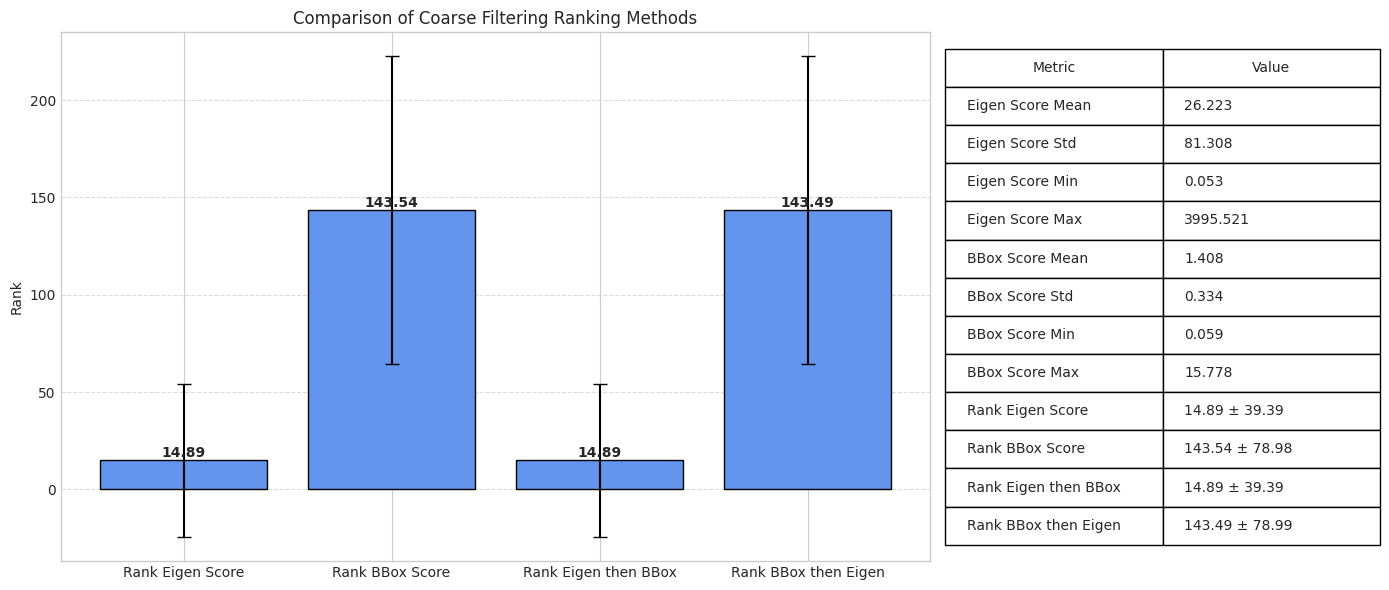

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Use a nice style for the figure
plt.style.use('seaborn-whitegrid')

# --- Compute metrics (assumed already computed) ---
# Filtering score statistics
eig_score_mean_value = df_rank_evaluations["eig_score_mean"].mean()
eig_score_std_value = df_rank_evaluations["eig_score_std"].std()
eig_score_min_value = df_rank_evaluations["eig_score_min"].min()
eig_score_max_value = df_rank_evaluations["eig_score_max"].max()

bbox_score_mean_value = df_rank_evaluations["bbox_score_mean"].mean()
bbox_score_std_value = df_rank_evaluations["bbox_score_std"].std()
bbox_score_min_value = df_rank_evaluations["bbox_score_min"].min()
bbox_score_max_value = df_rank_evaluations["bbox_score_max"].max()

# Ranking statistics
rank_eig_mean = df_rank_evaluations["eig_matching_index"].mean()
rank_eig_std = df_rank_evaluations["eig_matching_index"].std()
rank_bbox_mean = df_rank_evaluations["bbox_matching_index"].mean()
rank_bbox_std = df_rank_evaluations["bbox_matching_index"].std()
rank_eig_bbox_mean = df_rank_evaluations["eig_bbox_matching_index"].mean()
rank_eig_bbox_std = df_rank_evaluations["eig_bbox_matching_index"].std()
rank_bbox_eig_mean = df_rank_evaluations["bbox_eig_matching_index"].mean()
rank_bbox_eig_std = df_rank_evaluations["bbox_eig_matching_index"].std()

# --- Prepare the bar plot for ranking stats ---
methods = ["Rank Eigen Score", "Rank BBox Score", "Rank Eigen then BBox", "Rank BBox then Eigen"]
means = [rank_eig_mean, rank_bbox_mean, rank_eig_bbox_mean, rank_bbox_eig_mean]
stds  = [rank_eig_std, rank_bbox_std, rank_eig_bbox_std, rank_bbox_eig_std]

# Create a figure with two columns: one for the bar chart and one for the table
fig, (ax_bar, ax_table) = plt.subplots(ncols=2, figsize=(14, 6), gridspec_kw={'width_ratios': [2, 1]})

# Plot bar chart on the left axis
bars = ax_bar.bar(methods, means, yerr=stds, capsize=5, color='cornflowerblue', edgecolor='black')
ax_bar.set_ylabel("Rank")
ax_bar.set_title("Comparison of Coarse Filtering Ranking Methods")
ax_bar.grid(axis="y", linestyle="--", alpha=0.7)
for bar in bars:
    height = bar.get_height()
    ax_bar.text(bar.get_x() + bar.get_width()/2, height, f"{height:.2f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

# --- Prepare table data for filtering score and ranking stats ---
table_data = [
    ["Eigen Score Mean", f"{eig_score_mean_value:.3f}"],
    ["Eigen Score Std", f"{eig_score_std_value:.3f}"],
    ["Eigen Score Min", f"{eig_score_min_value:.3f}"],
    ["Eigen Score Max", f"{eig_score_max_value:.3f}"],
    ["BBox Score Mean", f"{bbox_score_mean_value:.3f}"],
    ["BBox Score Std", f"{bbox_score_std_value:.3f}"],
    ["BBox Score Min", f"{bbox_score_min_value:.3f}"],
    ["BBox Score Max", f"{bbox_score_max_value:.3f}"],
    ["Rank Eigen Score", f"{rank_eig_mean:.2f} ± {rank_eig_std:.2f}"],
    ["Rank BBox Score", f"{rank_bbox_mean:.2f} ± {rank_bbox_std:.2f}"],
    ["Rank Eigen then BBox", f"{rank_eig_bbox_mean:.2f} ± {rank_eig_bbox_std:.2f}"],
    ["Rank BBox then Eigen", f"{rank_bbox_eig_mean:.2f} ± {rank_bbox_eig_std:.2f}"],
]

# Turn off the axis for the table axis and add the table
ax_table.axis('off')
table = ax_table.table(cellText=table_data, colLabels=["Metric", "Value"], loc="center", cellLoc='left')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)  # Adjust scaling if needed

plt.tight_layout()
plt.show()

/tmp/ipykernel_12982/2444236285.py:6: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')


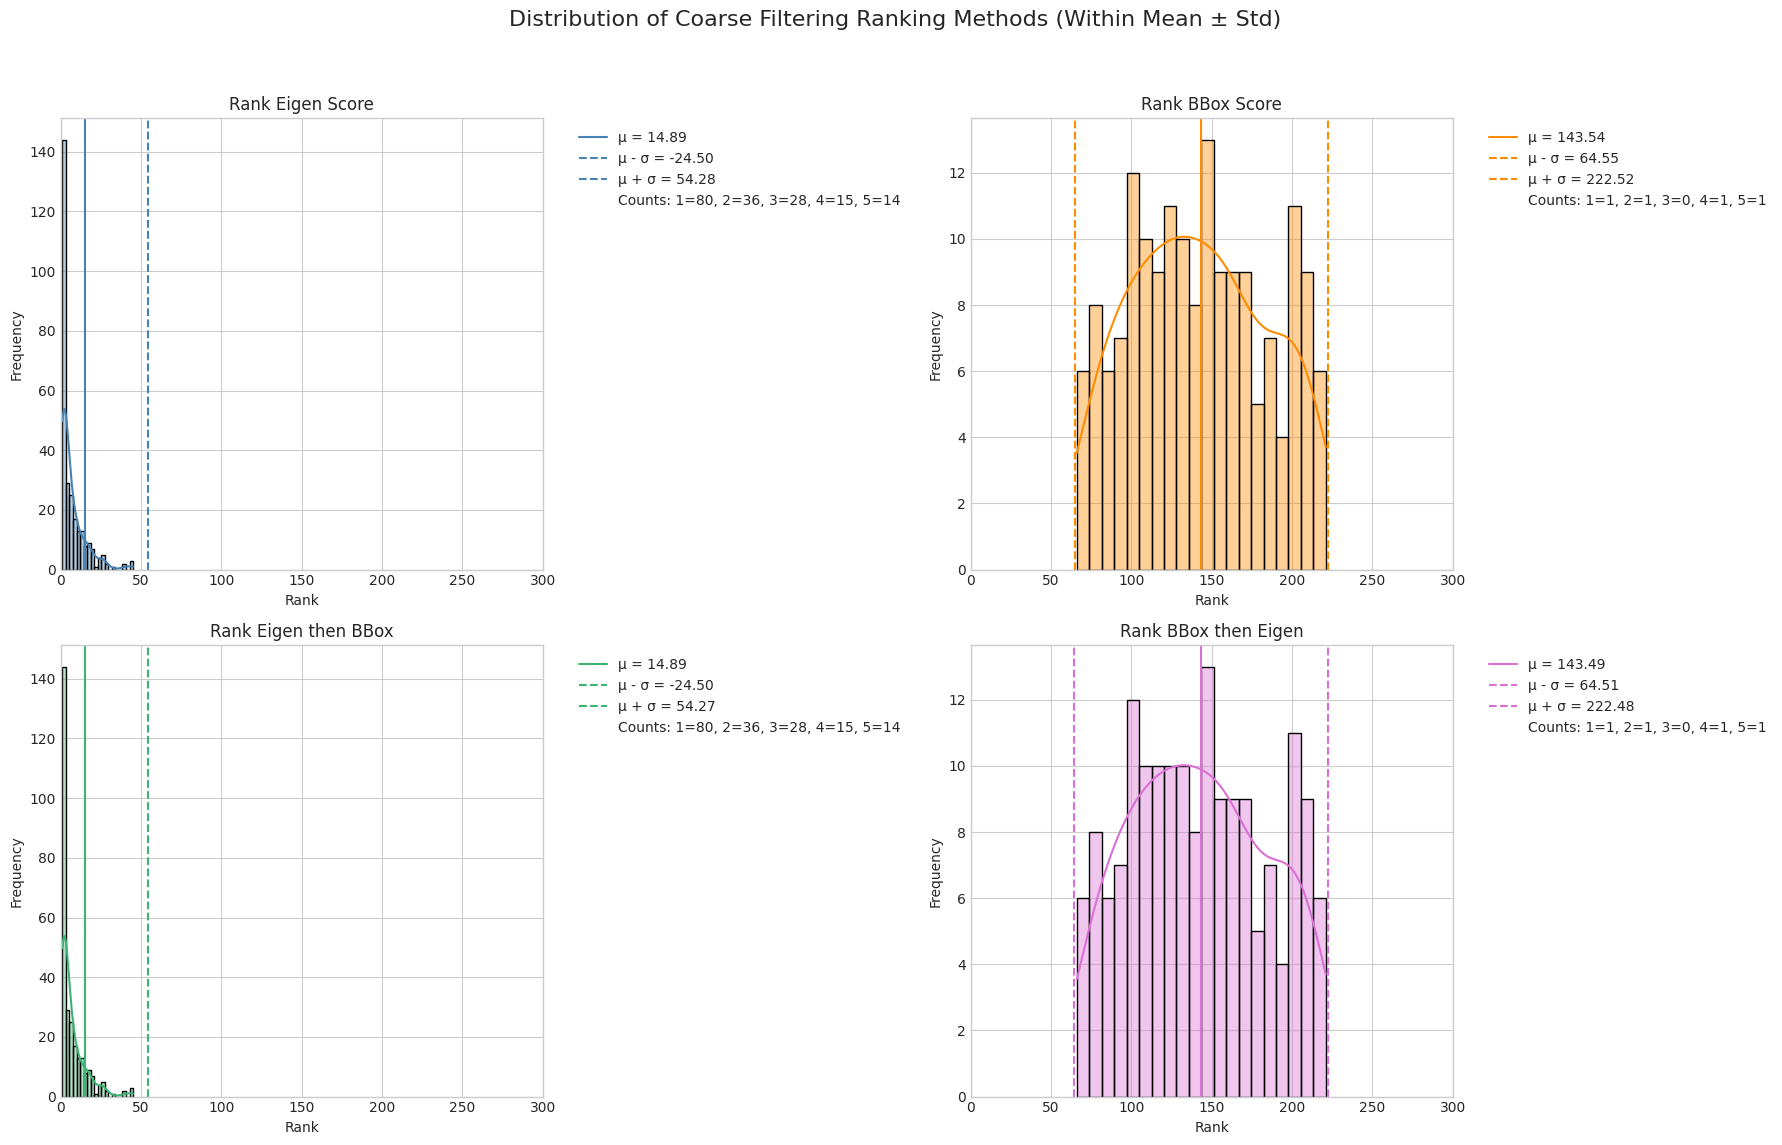

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.lines as mlines

# Set a clean style
plt.style.use('seaborn-whitegrid')

# Define the methods and corresponding titles for the plots
methods = ["eig_matching_index", "bbox_matching_index", "eig_bbox_matching_index", "bbox_eig_matching_index"]
titles = ["Rank Eigen Score", "Rank BBox Score", "Rank Eigen then BBox", "Rank BBox then Eigen"]
colors = ["steelblue", "darkorange", "mediumseagreen", "orchid"]

# Create a figure with 2x2 subplots
fig, axes = plt.subplots(ncols=2, nrows=2, figsize=(18, 12))
axes = axes.flatten()

for i, (col, color) in enumerate(zip(methods, colors)):
    data = df_rank_evaluations[col]
    m = data.mean()
    s = data.std()
    # Filter the data to include only values within [mean - std, mean + std]
    filtered = data[(data >= m - s) & (data <= m + s)]
    
    # Plot the histogram with a KDE overlay
    sns.histplot(filtered, bins=20, kde=True, ax=axes[i],
                 color=color, edgecolor='black', alpha=0.4)
    
    # Add vertical lines for mean ± std
    axes[i].axvline(m, color=color, linestyle='-', linewidth=1.5, label=f"μ = {m:.2f}")
    axes[i].axvline(m - s, color=color, linestyle='--', linewidth=1.5, label=f"μ - σ = {m-s:.2f}")
    axes[i].axvline(m + s, color=color, linestyle='--', linewidth=1.5, label=f"μ + σ = {m+s:.2f}")
    
    # Counts for top-5 ranks
    counts = {r: int((data == r).sum()) for r in [1, 2, 3, 4, 5]}
    counts_text = "Counts: " + ", ".join([f"{r}={counts[r]}" for r in sorted(counts.keys())])
    
    # Add counts as a dummy legend entry
    dummy_line = mlines.Line2D([], [], color='none', label=counts_text)
    handles, labels = axes[i].get_legend_handles_labels()
    handles.append(dummy_line)
    labels.append(counts_text)
    axes[i].legend(handles=handles, labels=labels, loc='upper left', bbox_to_anchor=(1.05, 1))
    
    axes[i].set_title(titles[i], fontsize=12)
    axes[i].set_xlabel("Rank", fontsize=10)
    axes[i].set_ylabel("Frequency", fontsize=10)
    axes[i].set_xlim(0, 300)

plt.suptitle("Distribution of Coarse Filtering Ranking Methods (Within Mean ± Std)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

/tmp/ipykernel_12982/3365157188.py:5: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')


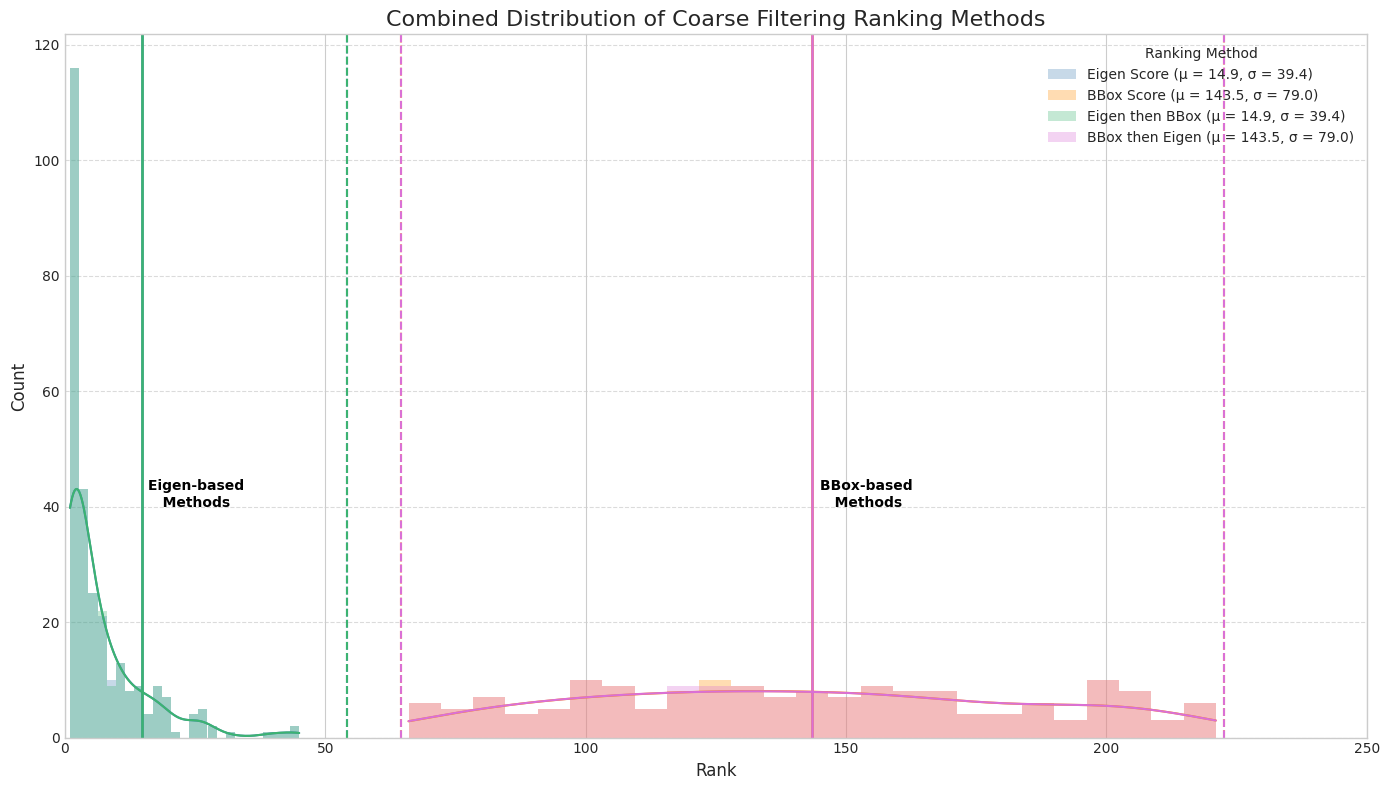

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean style
plt.style.use('seaborn-whitegrid')

# Define methods and their display titles
methods = ["eig_matching_index", "bbox_matching_index", 
           "eig_bbox_matching_index", "bbox_eig_matching_index"]
titles = ["Eigen Score", "BBox Score", "Eigen then BBox", "BBox then Eigen"]
colors = ["steelblue", "darkorange", "mediumseagreen", "orchid"]

# Create a single figure and axis
plt.figure(figsize=(14, 8))

# Plot each method on the same axis
for col, title, color in zip(methods, titles, colors):
    data = df_rank_evaluations[col]
    m = data.mean()
    s = data.std()
    filtered = data[(data >= m - s) & (data <= m + s)]
    
    # Plot histogram with KDE overlay
    sns.histplot(filtered, bins=25, kde=True, stat="count", 
             label=f"{title} (μ = {m:.1f}, σ = {s:.1f})", 
             color=color, fill=True, alpha=0.3, linewidth=0)
    
    # Add vertical lines for mean ± std
    plt.axvline(m, color=color, linestyle='-', linewidth=1.8)
    plt.axvline(m - s, color=color, linestyle='--', linewidth=1.5)
    plt.axvline(m + s, color=color, linestyle='--', linewidth=1.5)

# Plot styling
plt.title("Combined Distribution of Coarse Filtering Ranking Methods", fontsize=16)
plt.xlabel("Rank", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xlim(0, 250)  # Optional: zoom in on top 100
plt.legend(title="Ranking Method", fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.text(
    x=16, y=40,  # Position: adjust x and y as needed
    s="Eigen-based \n   Methods",
    fontsize=10,
    color="black",
    weight="bold"
)
plt.text(
    x=145, y=40,  # Position: adjust x and y as needed
    s="BBox-based \n   Methods",
    fontsize=10,
    color="black",
    weight="bold"
)
plt.tight_layout()
plt.show()

/tmp/ipykernel_7913/1281576786.py:5: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')


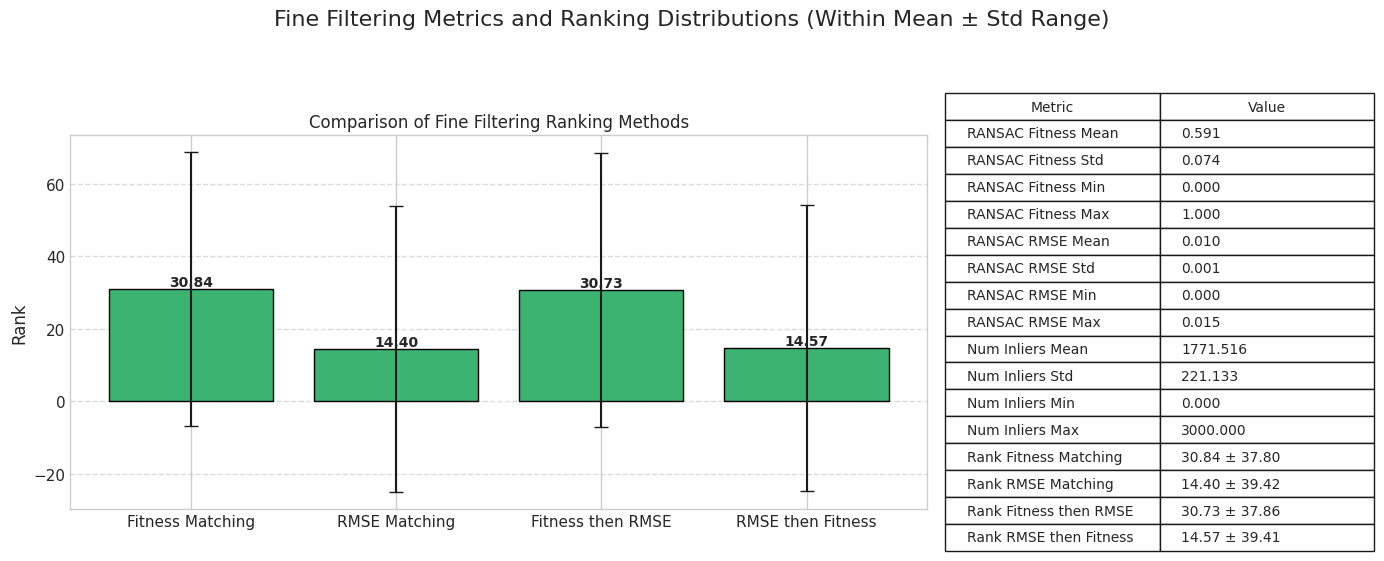

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a nice style
plt.style.use('seaborn-whitegrid')

# --- Compute fine filtering score statistics ---
ransac_fitness_mean_value = df_rank_evaluations["ransac_fitness_mean"].mean()
ransac_fitness_std_value = df_rank_evaluations["ransac_fitness_std"].std()
ransac_fitness_min_value = df_rank_evaluations["ransac_fitness_min"].min()
ransac_fitness_max_value = df_rank_evaluations["ransac_fitness_max"].max()

ransac_rmse_mean_value = df_rank_evaluations["ransac_rmse_mean"].mean()
ransac_rmse_std_value = df_rank_evaluations["ransac_rmse_std"].std()
ransac_rmse_min_value = df_rank_evaluations["ransac_rmse_min"].min()
ransac_rmse_max_value = df_rank_evaluations["ransac_rmse_max"].max()

num_inliers_mean_value = df_rank_evaluations["num_inliers_mean"].mean()
num_inliers_std_value = df_rank_evaluations["num_inliers_std"].std()
num_inliers_min_value = df_rank_evaluations["num_inliers_min"].min()
num_inliers_max_value = df_rank_evaluations["num_inliers_max"].max()

# --- Compute ranking statistics for fine filtering ---
# These ranking methods are:
# "fitness_matching_index", "rmse_matching_index", "fitness_rmse_matching_index", "rmse_fitness_matching_index"
rank_fitness_mean = df_rank_evaluations["fitness_matching_index"].mean()
rank_fitness_std = df_rank_evaluations["fitness_matching_index"].std()
rank_rmse_mean = df_rank_evaluations["rmse_matching_index"].mean()
rank_rmse_std = df_rank_evaluations["rmse_matching_index"].std()
rank_fitness_rmse_mean = df_rank_evaluations["fitness_rmse_matching_index"].mean()
rank_fitness_rmse_std = df_rank_evaluations["fitness_rmse_matching_index"].std()
rank_rmse_fitness_mean = df_rank_evaluations["rmse_fitness_matching_index"].mean()
rank_rmse_fitness_std = df_rank_evaluations["rmse_fitness_matching_index"].std()

# --- Prepare the bar plot for ranking statistics ---
methods = ["Fitness Matching", "RMSE Matching", "Fitness then RMSE", "RMSE then Fitness"]
means = [rank_fitness_mean, rank_rmse_mean, rank_fitness_rmse_mean, rank_rmse_fitness_mean]
stds = [rank_fitness_std, rank_rmse_std, rank_fitness_rmse_std, rank_rmse_fitness_std]

# Create a figure with two columns: left for the bar chart, right for the table
fig, (ax_bar, ax_table) = plt.subplots(ncols=2, figsize=(14, 6), gridspec_kw={'width_ratios': [2, 1]})

# Bar plot on the left
bars = ax_bar.bar(methods, means, yerr=stds, capsize=5, color='mediumseagreen', edgecolor='black')
ax_bar.set_ylabel("Rank")
ax_bar.set_title("Comparison of Fine Filtering Ranking Methods")
ax_bar.grid(axis="y", linestyle="--", alpha=0.7)
for bar in bars:
    height = bar.get_height()
    ax_bar.text(bar.get_x() + bar.get_width()/2, height, f"{height:.2f}", ha="center", va="bottom",
                fontsize=10, fontweight="bold")

# --- Prepare table data for fine filtering metrics ---
table_data = [
    ["RANSAC Fitness Mean", f"{ransac_fitness_mean_value:.3f}"],
    ["RANSAC Fitness Std", f"{ransac_fitness_std_value:.3f}"],
    ["RANSAC Fitness Min", f"{ransac_fitness_min_value:.3f}"],
    ["RANSAC Fitness Max", f"{ransac_fitness_max_value:.3f}"],
    ["RANSAC RMSE Mean", f"{ransac_rmse_mean_value:.3f}"],
    ["RANSAC RMSE Std", f"{ransac_rmse_std_value:.3f}"],
    ["RANSAC RMSE Min", f"{ransac_rmse_min_value:.3f}"],
    ["RANSAC RMSE Max", f"{ransac_rmse_max_value:.3f}"],
    ["Num Inliers Mean", f"{num_inliers_mean_value:.3f}"],
    ["Num Inliers Std", f"{num_inliers_std_value:.3f}"],
    ["Num Inliers Min", f"{num_inliers_min_value:.3f}"],
    ["Num Inliers Max", f"{num_inliers_max_value:.3f}"],
    ["Rank Fitness Matching", f"{rank_fitness_mean:.2f} ± {rank_fitness_std:.2f}"],
    ["Rank RMSE Matching", f"{rank_rmse_mean:.2f} ± {rank_rmse_std:.2f}"],
    ["Rank Fitness then RMSE", f"{rank_fitness_rmse_mean:.2f} ± {rank_fitness_rmse_std:.2f}"],
    ["Rank RMSE then Fitness", f"{rank_rmse_fitness_mean:.2f} ± {rank_rmse_fitness_std:.2f}"],
]

# Turn off axis for the table subplot and add the table
ax_table.axis('off')
table = ax_table.table(cellText=table_data, colLabels=["Metric", "Value"], loc="center", cellLoc='left')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)  # Adjust vertical scaling as needed

plt.suptitle("Fine Filtering Metrics and Ranking Distributions (Within Mean ± Std Range)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

/tmp/ipykernel_12982/3405415868.py:6: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')


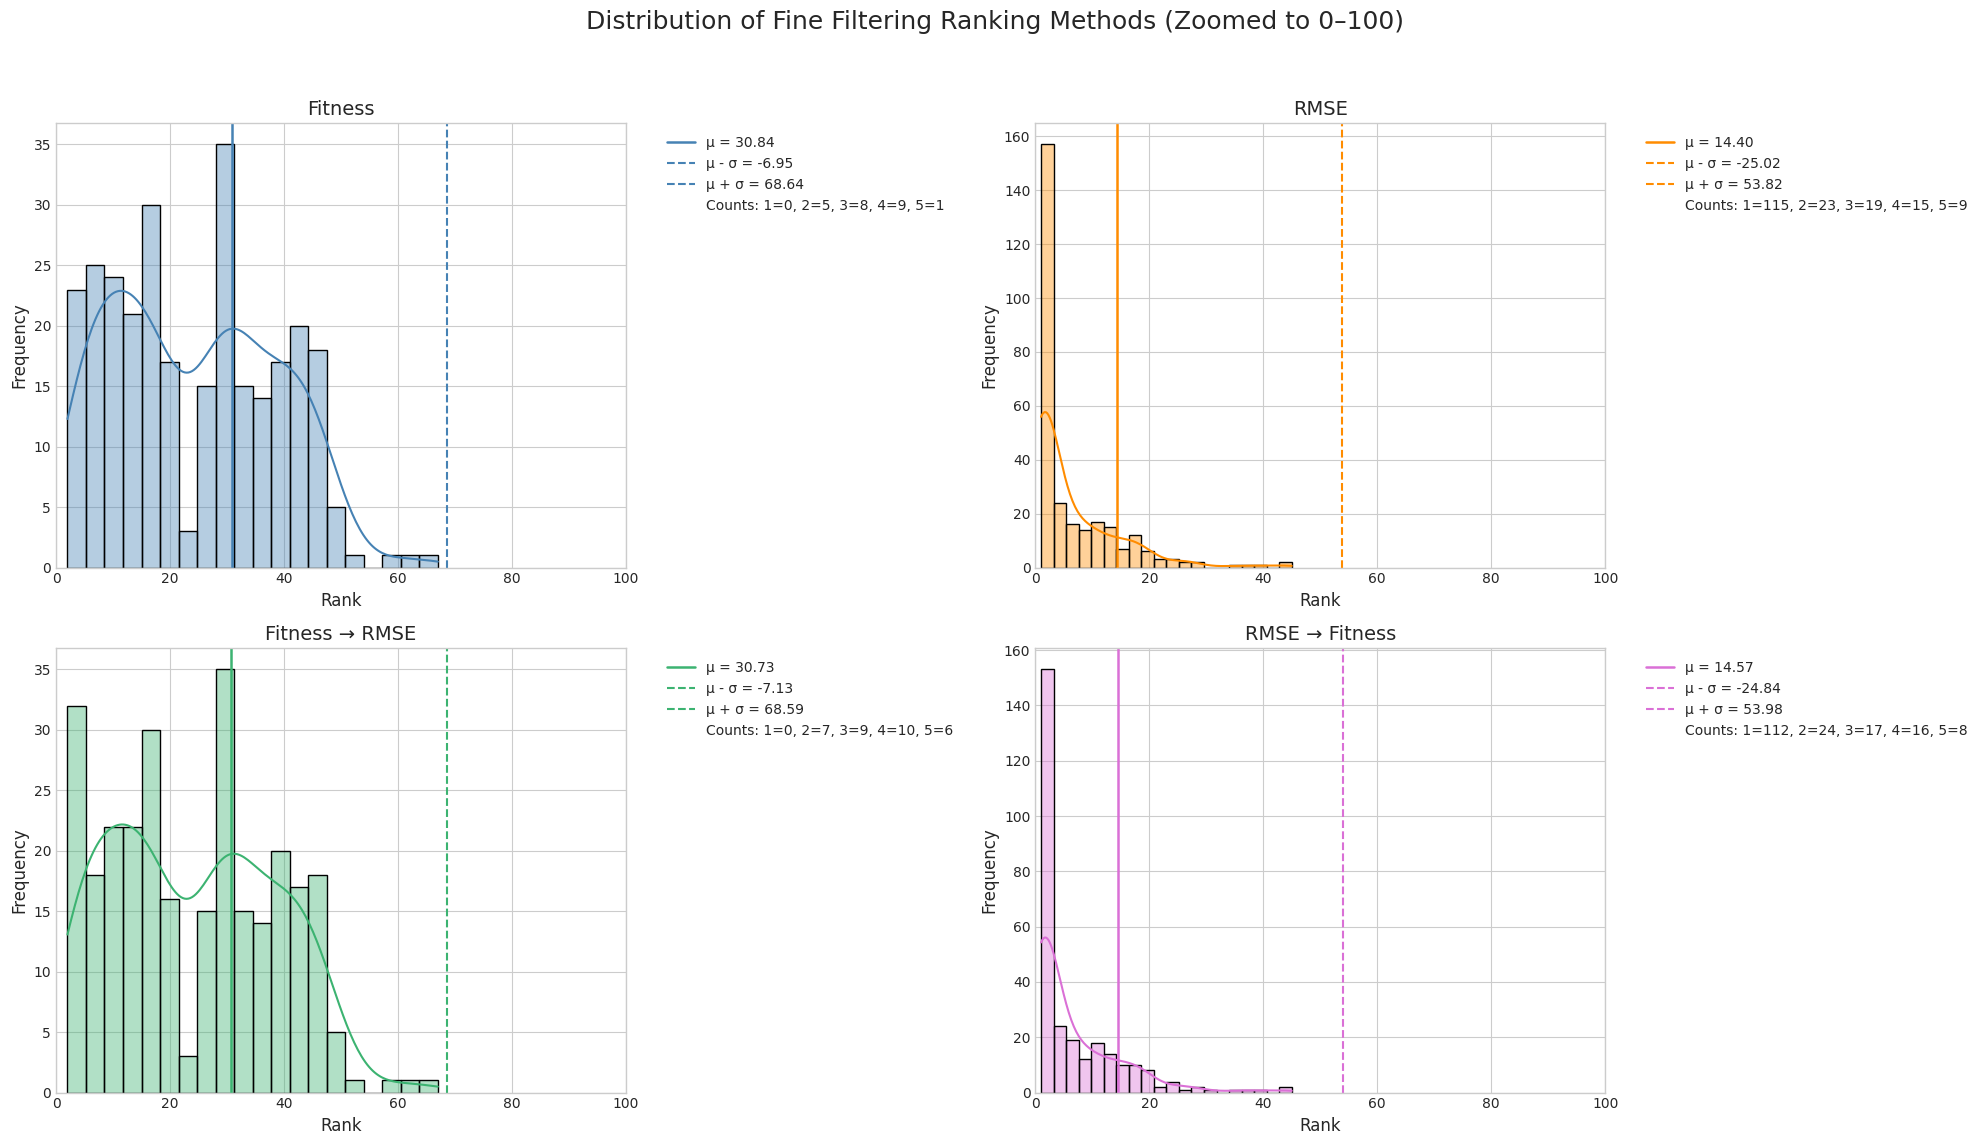

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.lines as mlines

# Set a clean style
plt.style.use('seaborn-whitegrid')

# Define the fine filtering ranking methods and corresponding titles for the plots
methods = ["fitness_matching_index", "rmse_matching_index", 
           "fitness_rmse_matching_index", "rmse_fitness_matching_index"]
titles = ["Fitness", "RMSE", "Fitness → RMSE", "RMSE → Fitness"]
colors = ["steelblue", "darkorange", "mediumseagreen", "orchid"]

# Create a figure with 2x2 subplots with a larger size
fig, axes = plt.subplots(ncols=2, nrows=2, figsize=(20, 12))
axes = axes.flatten()

for i, (col, color) in enumerate(zip(methods, colors)):
    data = df_rank_evaluations[col]
    m = data.mean()
    s = data.std()
    filtered = data[(data >= m - s) & (data <= m + s)]
    
    # Plot histogram with KDE overlay
    sns.histplot(filtered, bins=20, kde=True, ax=axes[i],
                 color=color, edgecolor='black', alpha=0.4)
    
    # Draw vertical lines for mean ± std
    axes[i].axvline(m, color=color, linestyle='-', linewidth=1.8, label=f"μ = {m:.2f}")
    axes[i].axvline(m - s, color=color, linestyle='--', linewidth=1.5, label=f"μ - σ = {m-s:.2f}")
    axes[i].axvline(m + s, color=color, linestyle='--', linewidth=1.5, label=f"μ + σ = {m+s:.2f}")
    
    axes[i].set_title(titles[i], fontsize=14)
    axes[i].set_xlabel("Rank", fontsize=12)
    axes[i].set_ylabel("Frequency", fontsize=12)
    
    # Counts for top-5 ranks
    counts = {r: int((data == r).sum()) for r in [1, 2, 3, 4, 5]}
    counts_text = "Counts: " + ", ".join([f"{r}={counts[r]}" for r in sorted(counts.keys())])
    
    # Dummy legend entry for counts
    dummy_line = mlines.Line2D([], [], color='none', label=counts_text)
    handles, labels = axes[i].get_legend_handles_labels()
    handles.append(dummy_line)
    labels.append(counts_text)
    
    axes[i].legend(handles=handles, labels=labels, loc='upper left', bbox_to_anchor=(1.05, 1))
    axes[i].set_xlim(0, 100)

plt.suptitle("Distribution of Fine Filtering Ranking Methods (Zoomed to 0–100)", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

/tmp/ipykernel_12982/3626114124.py:5: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')


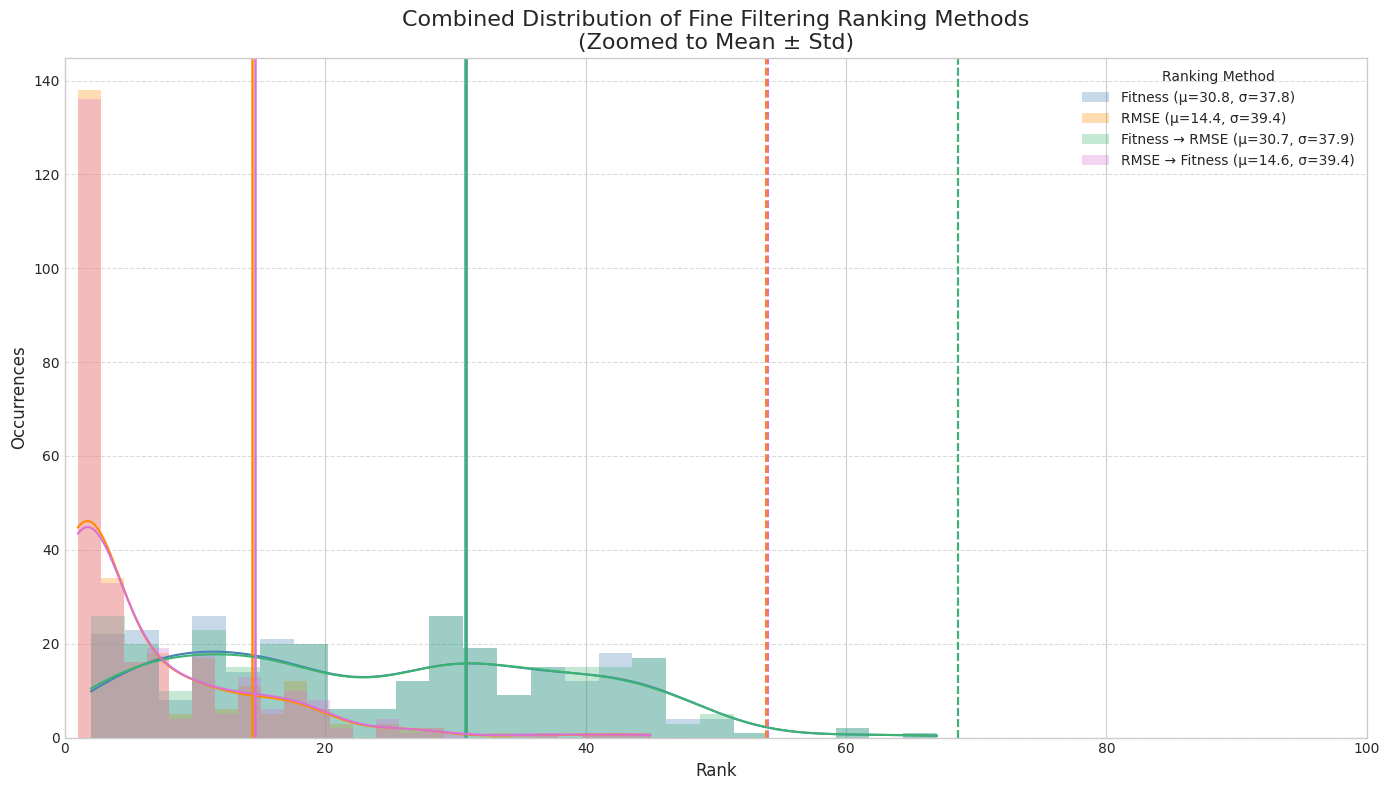

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean style
plt.style.use('seaborn-whitegrid')

# Define methods and their display titles
methods = ["fitness_matching_index", "rmse_matching_index", 
           "fitness_rmse_matching_index", "rmse_fitness_matching_index"]
titles = ["Fitness", "RMSE", "Fitness → RMSE", "RMSE → Fitness"]
colors = ["steelblue", "darkorange", "mediumseagreen", "orchid"]

# Create a single figure and axis
plt.figure(figsize=(14, 8))

# Plot each method on the same axis
for col, label, color in zip(methods, titles, colors):
    data = df_rank_evaluations[col]
    m = data.mean()
    s = data.std()
    filtered = data[(data >= m - s) & (data <= m + s)]

    # Plot histogram with KDE overlay (filled and translucent)
    sns.histplot(filtered, bins=25, kde=True, stat="count",
                 label=f"{label} (μ={m:.1f}, σ={s:.1f})",
                 color=color, fill=True, alpha=0.3, linewidth=0)

    # Add vertical lines for mean ± std
    plt.axvline(m, color=color, linestyle='-', linewidth=1.8)
    plt.axvline(m - s, color=color, linestyle='--', linewidth=1.5)
    plt.axvline(m + s, color=color, linestyle='--', linewidth=1.5)

# Final plot styling
plt.title("Combined Distribution of Fine Filtering Ranking Methods\n(Zoomed to Mean ± Std)", fontsize=16)
plt.xlabel("Rank", fontsize=12)
plt.ylabel("Occurrences", fontsize=12)
plt.xlim(0, 100)
plt.legend(title="Ranking Method", fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()